# Artefato 2: Modelo Clássico Baseline (Machine Learning Tradicional)

## Objetivo

Este notebook implementa **modelos baseline** utilizando técnicas de **Machine Learning clássico** para classificação de imagens de satélite. O objetivo é estabelecer uma linha de base de desempenho que servirá como referência para comparação com modelos mais avançados (como redes neurais profundas).

### Modelos Implementados:
1. **Random Forest** - Ensemble de árvores de decisão
2. **SVM Linear** - Support Vector Machine com kernel linear
3. **Regressão Logística** - Modelo linear com regularização L2

### Critérios de Aceitação (Artefato 1, Seção 1.3):
- ROC-AUC >= 0.70
- F1-score >= 0.60
- Recall >= 0.65

## 1. Imports e Configuração

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Resolve a raiz do repositorio para imports internos
repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.utils.prepare_dataset import prepare_dataset

## 2. Carregamento dos Dados

Carrega o dataset tabular de pixels com rótulos derivados de `extracted_codes.json`. Cada amostra contém os valores de pixels de todas as bandas espectrais de uma imagem de satélite.


O dataset utilizado (`pixels_dataset.csv`) consiste em amostras de pixels extraídos das imagens ASTER.
* **Features:** Bandas espectrais (VNIR, SWIR, TIR) que capturam a assinatura mineralógica.
* **Target:** Rótulo binário (1 = Presença de Terras Raras/Alteração, 0 = Ausência).
Este formato tabular permite a aplicação direta de algoritmos clássicos (Random Forest, SVM, etc.) que não processam a imagem como uma matriz espacial, mas sim pixel a pixel.

In [ ]:
PIXELS_DATASET_PATH = str(repo_root / "data" / "pixels_dataset.csv")
EXTRACTED_CODES_PATH = str(repo_root / "data" / "extracted_codes.json")

X, y = prepare_dataset(PIXELS_DATASET_PATH, EXTRACTED_CODES_PATH)

# Remove amostras sem label valido (-1)
valid_mask = y != -1
X, y = X[valid_mask].reset_index(drop=True), y[valid_mask].reset_index(drop=True)

print(f"Features: {X.shape}")
print(f"Labels:   {y.shape}")
print(f"\nDistribuicao das classes:\n{y.value_counts()}")

Features: (295, 147456)
Labels:   (295,)

Distribuicao das classes:
label
0    179
1    116
Name: count, dtype: int64


## 3. Divisão Treino / Teste (Stratified)

Separa 80% para treino e 20% para teste, mantendo a proporção de classes com `stratify`. O `random_state=42` garante reprodutibilidade. A mesma divisão é utilizada para todos os modelos, permitindo comparação direta.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape}  |  positivos={sum(y_train==1)}, negativos={sum(y_train==0)}")
print(f"Teste:   {X_test.shape}  |  positivos={sum(y_test==1)}, negativos={sum(y_test==0)}")

Treino:  (236, 147456)  |  positivos=93, negativos=143
Teste:   (59, 147456)  |  positivos=23, negativos=36


## 4. Função de Avaliação

Função utilitária que padroniza a avaliação de todos os modelos, exibindo:
- Métricas de classificação (Accuracy, Precision, Recall, F1, ROC-AUC)
- Verificação dos critérios de aceitação
- Classification Report
- Matriz de Confusão e Curva ROC

In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    """Avalia o modelo e exibe metricas, classification report, matriz de confusao e curva ROC."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-score":  f1_score(y_test, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob)

    # Metricas
    print("=" * 45)
    print(f"  {model_name}")
    print("=" * 45)
    for name, value in metrics.items():
        print(f"  {name:<12s}: {value:.4f}")
    print("=" * 45)

    # Criterios de aceitacao
    print("\nCriterios de aceitacao:")
    if "ROC-AUC" in metrics:
        status = "OK" if metrics["ROC-AUC"] >= 0.70 else "ABAIXO"
        print(f"  ROC-AUC >= 0.70 : {status} ({metrics['ROC-AUC']:.4f})")
    status = "OK" if metrics["F1-score"] >= 0.60 else "ABAIXO"
    print(f"  F1-score >= 0.60: {status} ({metrics['F1-score']:.4f})")
    status = "OK" if metrics["Recall"] >= 0.65 else "ABAIXO"
    print(f"  Recall >= 0.65  : {status} ({metrics['Recall']:.4f})")

    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))

    # Matriz de Confusao + Curva ROC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Negativo", "Positivo"],
        cmap="Blues",
        ax=axes[0],
    )
    axes[0].set_title(f"Matriz de Confusao - {model_name}")

    if y_prob is not None:
        RocCurveDisplay.from_predictions(
            y_test, y_prob,
            name=model_name,
            ax=axes[1],
        )
        axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatorio")
        axes[1].set_title(f"Curva ROC - {model_name}")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics

---
## 5. Random Forest

Ensemble de 300 árvores de decisão. Modelo robusto e interpretável, com capacidade natural de lidar com dados de alta dimensionalidade.

**Configuração**: `n_estimators=300`, `random_state=42`, pré-processamento com `StandardScaler`.

  Random Forest
  Accuracy    : 0.8644
  Precision   : 0.8947
  Recall      : 0.7391
  F1-score    : 0.8095
  ROC-AUC     : 0.9336

Criterios de aceitacao:
  ROC-AUC >= 0.70 : OK (0.9336)
  F1-score >= 0.60: OK (0.8095)
  Recall >= 0.65  : OK (0.7391)

Classification Report:
              precision    recall  f1-score   support

Negativo (0)       0.85      0.94      0.89        36
Positivo (1)       0.89      0.74      0.81        23

    accuracy                           0.86        59
   macro avg       0.87      0.84      0.85        59
weighted avg       0.87      0.86      0.86        59



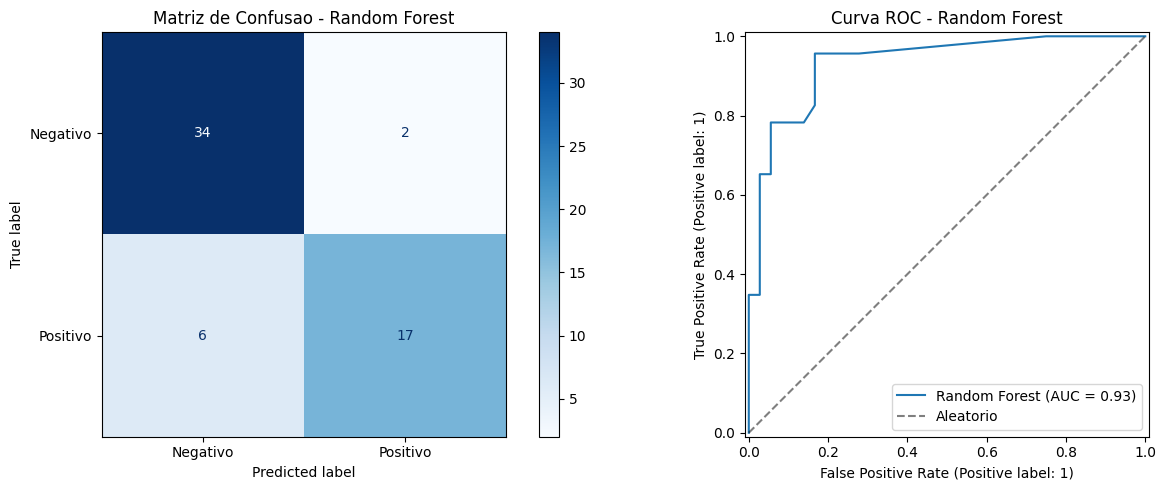

In [6]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42)),
])

rf_pipeline.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

---
## 6. SVM Linear

Support Vector Machine com kernel linear. Eficaz para dados de alta dimensionalidade onde o número de features supera o número de amostras.

### 6.1 Ajuste do hiperparâmetro C via GridSearchCV

Pipeline `StandardScaler` + `SVC(kernel='linear')` com diferentes valores de `C` testados via validação cruzada estratificada (5-fold). A métrica de seleção é o F1-score.

In [7]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True, random_state=42)),
])

param_grid = {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svm_pipeline, param_grid, cv=cv, scoring="f1",
    return_train_score=True, n_jobs=-1, verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nMelhor C: {grid_search.best_params_['svm__C']}")
print(f"Melhor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Melhor C: 0.001
Melhor F1 (CV): 0.7658


### 6.2 Resultados da busca de C

Visualiza o F1-score médio de treino e validação para cada valor de C testado.

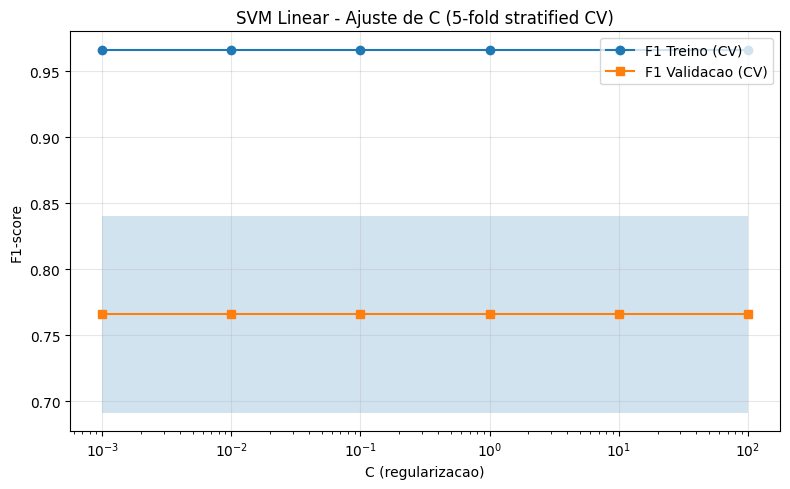


Resumo por valor de C:
      C  F1 Treino (media)  F1 Val (media)  F1 Val (std)
  0.001           0.966625        0.765848      0.074599
  0.010           0.966625        0.765848      0.074599
  0.100           0.966625        0.765848      0.074599
  1.000           0.966625        0.765848      0.074599
 10.000           0.966625        0.765848      0.074599
100.000           0.966625        0.765848      0.074599


In [8]:
results_df = pd.DataFrame(grid_search.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))
c_values = results_df["param_svm__C"].astype(float)
ax.plot(c_values, results_df["mean_train_score"], "o-", label="F1 Treino (CV)")
ax.plot(c_values, results_df["mean_test_score"], "s-", label="F1 Validacao (CV)")
ax.fill_between(
    c_values,
    results_df["mean_test_score"] - results_df["std_test_score"],
    results_df["mean_test_score"] + results_df["std_test_score"],
    alpha=0.2,
)
ax.set_xscale("log")
ax.set_xlabel("C (regularizacao)")
ax.set_ylabel("F1-score")
ax.set_title("SVM Linear - Ajuste de C (5-fold stratified CV)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResumo por valor de C:")
summary = results_df[["param_svm__C", "mean_train_score", "mean_test_score", "std_test_score"]]
summary.columns = ["C", "F1 Treino (media)", "F1 Val (media)", "F1 Val (std)"]
print(summary.to_string(index=False))

### 6.3 Avaliação no conjunto de teste

  SVM Linear (C=0.001)
  Accuracy    : 0.8644
  Precision   : 0.8571
  Recall      : 0.7826
  F1-score    : 0.8182
  ROC-AUC     : 0.9233

Criterios de aceitacao:
  ROC-AUC >= 0.70 : OK (0.9233)
  F1-score >= 0.60: OK (0.8182)
  Recall >= 0.65  : OK (0.7826)

Classification Report:
              precision    recall  f1-score   support

Negativo (0)       0.87      0.92      0.89        36
Positivo (1)       0.86      0.78      0.82        23

    accuracy                           0.86        59
   macro avg       0.86      0.85      0.86        59
weighted avg       0.86      0.86      0.86        59



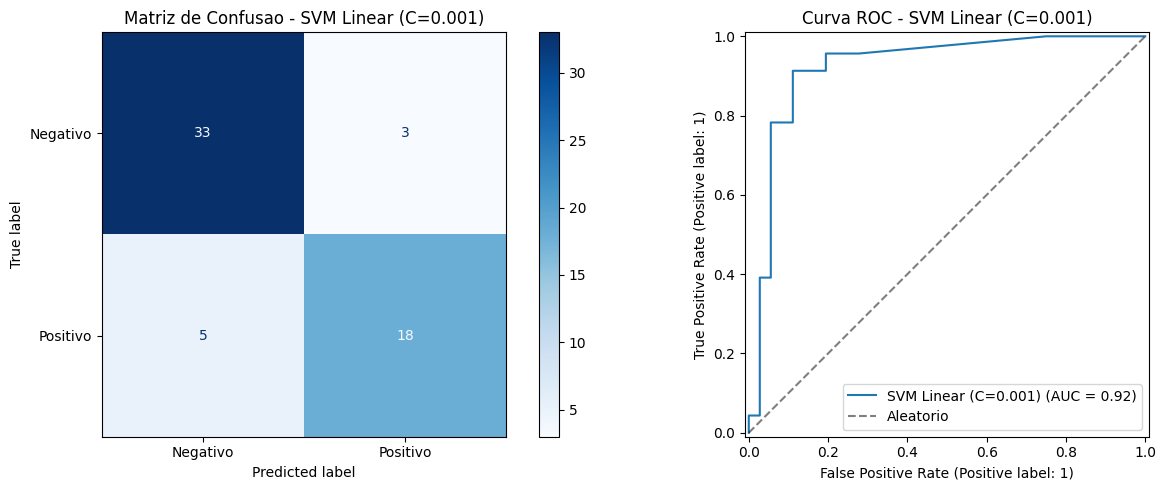

In [9]:
best_svm = grid_search.best_estimator_
svm_metrics = evaluate_model(best_svm, X_test, y_test, f"SVM Linear (C={grid_search.best_params_['svm__C']})")

### 6.4 Validação cruzada completa (5-fold) com o melhor C

Estimativa mais robusta do desempenho com validação cruzada estratificada no conjunto de treino.

In [10]:
best_C = grid_search.best_params_["svm__C"]

final_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=best_C, probability=True, random_state=42)),
])

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print(f"Validacao cruzada (5-fold) com C={best_C}\n")
for metric in scoring_metrics:
    scores = cross_val_score(final_svm_pipeline, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    print(f"  {metric:<12s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Validacao cruzada (5-fold) com C=0.001

  accuracy    : 0.8138 (+/- 0.0565)
  precision   : 0.7587 (+/- 0.0688)
  recall      : 0.7754 (+/- 0.0889)
  f1          : 0.7658 (+/- 0.0746)
  roc_auc     : 0.8535 (+/- 0.0620)


---
## 7. Regressão Logística

Modelo linear com regularização L2. Simples, rápido e serve como baseline interpretável.

**Configuração**: `C=1.0`, `solver='lbfgs'`, `max_iter=1000`, `random_state=42`, pré-processamento com `StandardScaler`.

  Regressao Logistica
  Accuracy    : 0.8644
  Precision   : 0.8571
  Recall      : 0.7826
  F1-score    : 0.8182
  ROC-AUC     : 0.8557

Criterios de aceitacao:
  ROC-AUC >= 0.70 : OK (0.8557)
  F1-score >= 0.60: OK (0.8182)
  Recall >= 0.65  : OK (0.7826)

Classification Report:
              precision    recall  f1-score   support

Negativo (0)       0.87      0.92      0.89        36
Positivo (1)       0.86      0.78      0.82        23

    accuracy                           0.86        59
   macro avg       0.86      0.85      0.86        59
weighted avg       0.86      0.86      0.86        59



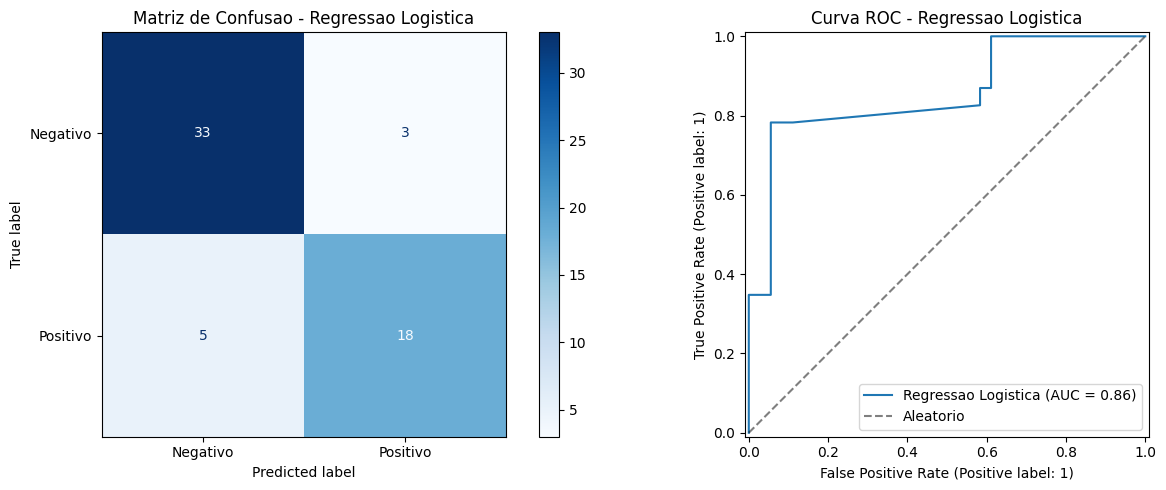

In [11]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model(lr_pipeline, X_test, y_test, "Regressao Logistica")

---
## 8. Comparação dos Modelos

Tabela consolidada com as métricas de todos os baselines para referência nos próximos artefatos.

In [12]:
summary_data = []
for name, m in [("Random Forest", rf_metrics), ("SVM Linear", svm_metrics), ("Regressao Logistica", lr_metrics)]:
    row = {"Modelo": name}
    row.update({k: round(v, 4) for k, v in m.items()})
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

             Modelo  Accuracy  Precision  Recall  F1-score  ROC-AUC
      Random Forest    0.8644     0.8947  0.7391    0.8095   0.9336
         SVM Linear    0.8644     0.8571  0.7826    0.8182   0.9233
Regressao Logistica    0.8644     0.8571  0.7826    0.8182   0.8557


## 9. Análise Crítica e Conclusão

**1. Comparação de Modelos e Impacto no Negócio:**
Todos os modelos superaram o baseline (ROC-AUC > 0.70), mas houve um *trade-off* claro:
* **Random Forest:** Melhor **Precisão (0.89)** e **AUC (0.93)**. É o modelo mais seguro para a *Frontera Minerals*, pois minimiza o envio de equipes para locais sem minério (reduz custos operacionais/falsos positivos).
* **Modelos Lineares:** Melhor **Recall (0.78)**. Recuperam mais depósitos, mas com mais ruído.
* **Decisão:** O Random Forest é o vencedor por capturar melhor a não-linearidade das bandas espectrais.

**2. Análise de Erros (Limitação dos Métodos Clássicos):**
A principal falha observada é a **ausência de contexto espacial**. Como os modelos analisam apenas pixel a pixel (cor), eles geram:
* **Fragmentação (Ruído):** Pixels isolados classificados como minério em áreas de vegetação.
* **Falta de Continuidade:** Incapacidade de reconhecer a forma e textura de um corpo mineral geológico.

**3. Justificativa para Deep Learning (Próxima Etapa):**
A transição para **Redes Neurais Convolucionais (CNNs)** é necessária para superar a limitação acima. Diferente do Random Forest, as CNNs analisarão a **vizinhança do pixel** (janelas de imagem), aprendendo padrões de textura e forma. Isso deve reduzir drasticamente o ruído e aumentar a assertividade na detecção de depósitos reais.

### Próximos Passos:
1. **Feature Engineering**: Explorar features derivadas (índices espectrais, texturas)
2. **Hyperparameter Tuning**: Otimizar parâmetros dos modelos com melhor desempenho
3. **Modelos Avançados**: Testar redes neurais convolucionais (CNNs)
4. **Análise de Erros**: Investigar casos de falsos positivos e falsos negativos